# Air Pollution in Ulaanbaatar, Mongolia

## CS215 Final Project
Arvin Shirchindorj

May 16, 2026


## Final Project Overview

In this project, I study air pollution in Ulaanbaatar, Mongolia using daily air quality data and daily weather data from 2016 to 2019. My main goal is to understand how pollution in Ulaanbaatar changes over time, how it differs across monitoring stations, and how weather conditions may be associated with daily pollution levels.

I have worked on a different Collab Notebook to collect and clean all my data.
Data Collection and Cleaning Process: https://colab.research.google.com/drive/13dCSLN7O3z_UkbsOajGKndp0dprOL5Uo?usp=sharing

In [1]:
# Load the main analysis datasets prepared in the data notebook.
# These files will be used for the main project questions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

air_monthly_city_df = pd.read_csv("/content/air_monthly_city_pollutant.csv")
air_station_summary_df = pd.read_csv("/content/air_station_summary_pollutant.csv")
air_weather_daily_df = pd.read_csv("/content/air_weather_daily_merged.csv")
air_clean_df = pd.read_csv("/content/ulaanbaatar_air_daily_clean.csv")

# How do major air pollutants in Ulaanbaatar vary across seasons and years?

I wanted to start with the time patterns in the data because this gives a clear overall picture of air pollution in Ulaanbaatar. I will look at how the main pollutants change across seasons and years. This should help show whether pollution is stable throughout the year or whether some periods are much worse than others.

In [2]:
# Inspect the monthly city-level pollutant dataset before making plots.

print("Pollutants in monthly dataset:")
print(sorted(air_monthly_city_df["parameter"].unique()))

print("\nYears in monthly dataset:")
print(sorted(air_monthly_city_df["year"].unique()))

print("\nFirst 5 rows of monthly dataset:")
display(air_monthly_city_df.head())

Pollutants in monthly dataset:
['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']

Years in monthly dataset:
[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]

First 5 rows of monthly dataset:


,year,month,season,parameter,avg_value,median_value,min_value,max_value,number_of_readings,avg_percent_coverage
0,2016,1,Winter,co,2341.619048,1710.000,524.00,6130.0,21,72.238095
1,2016,1,Winter,no2,74.711111,80.400,35.00,120.0,18,74.333333
2,2016,1,Winter,o3,12.082500,9.715,1.42,28.2,20,71.700000
3,2016,1,Winter,pm10,237.360870,180.000,96.30,876.0,23,66.304348
4,2016,1,Winter,pm25,242.485714,209.500,88.80,516.0,14,70.571429


In [4]:
# Calculate seasonal average pollution levels for each pollutant.
season_order = ["Winter", "Spring", "Summer", "Fall"]

seasonal_summary_df = (
    air_monthly_city_df
    .groupby(["parameter", "season"], as_index=False)["avg_value"]
    .mean()
)

seasonal_summary_df["season"] = pd.Categorical(
    seasonal_summary_df["season"],
    categories=season_order,
    ordered=True
)

seasonal_summary_df = seasonal_summary_df.sort_values(["parameter", "season"])

display(seasonal_summary_df)

,parameter,season,avg_value
3,co,Winter,2111.831988
1,co,Spring,598.272947
2,co,Summer,459.444809
0,co,Fall,1032.707195
7,no2,Winter,55.498540
5,no2,Spring,29.831421
6,no2,Summer,23.996435
4,no2,Fall,37.617968
11,o3,Winter,15.436325
9,o3,Spring,42.519617


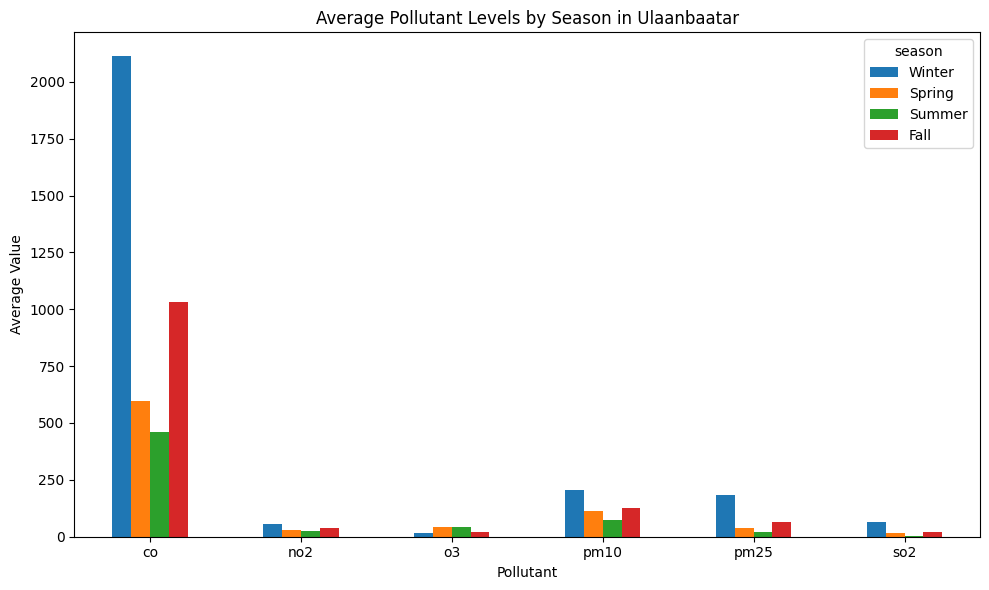

In [66]:
# Plot average pollutant levels by season.

pivot_seasonal_df = seasonal_summary_df.pivot(
    index="parameter",
    columns="season",
    values="avg_value"
)

pivot_seasonal_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average Pollutant Levels by Season in Ulaanbaatar")
plt.xlabel("Pollutant")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/project_website_figures/seasonal_pollutant_levels.png", dpi=300, bbox_inches="tight")
plt.show()

The seasonal bar chart gives a first overview, but I also want to measure how extreme the seasonal differences really are. To do that, I compare winter and summer averages directly for each pollutant and calculate a winter-to-summer ratio.

In [6]:
# Compare winter and summer average pollution levels directly.

winter_summer_df = seasonal_summary_df[
    seasonal_summary_df["season"].isin(["Winter", "Summer"])
].copy()

winter_summer_pivot = winter_summer_df.pivot(
    index="parameter",
    columns="season",
    values="avg_value"
).reset_index()

winter_summer_pivot["winter_to_summer_ratio"] = (
    winter_summer_pivot["Winter"] / winter_summer_pivot["Summer"]
)

winter_summer_pivot = winter_summer_pivot.sort_values(
    "winter_to_summer_ratio",
    ascending=False
)

display(winter_summer_pivot)

season,parameter,Winter,Summer,winter_to_summer_ratio
5,so2,64.310923,4.771878,13.477066
4,pm25,184.475933,21.015273,8.778184
0,co,2111.831988,459.444809,4.596487
3,pm10,205.332853,73.679013,2.786857
1,no2,55.498540,23.996435,2.312783
2,o3,15.436325,40.572087,0.380467


In [7]:
# Create a year-month label so the monthly trend plots are easier to read.

air_monthly_city_df["year_month"] = pd.to_datetime(
    air_monthly_city_df["year"].astype(str) + "-" + air_monthly_city_df["month"].astype(str) + "-01"
)

display(air_monthly_city_df[["year", "month", "year_month", "parameter", "avg_value"]].head())

,year,month,year_month,parameter,avg_value
0,2016,1,2016-01-01,co,2341.619048
1,2016,1,2016-01-01,no2,74.711111
2,2016,1,2016-01-01,o3,12.082500
3,2016,1,2016-01-01,pm10,237.360870
4,2016,1,2016-01-01,pm25,242.485714


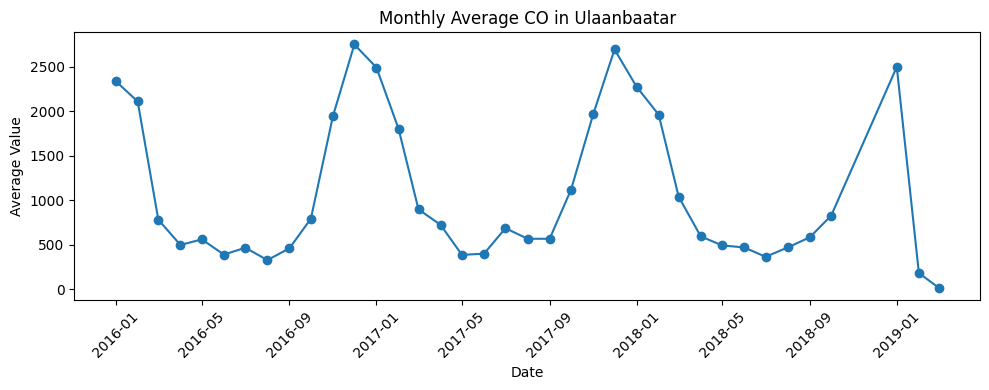

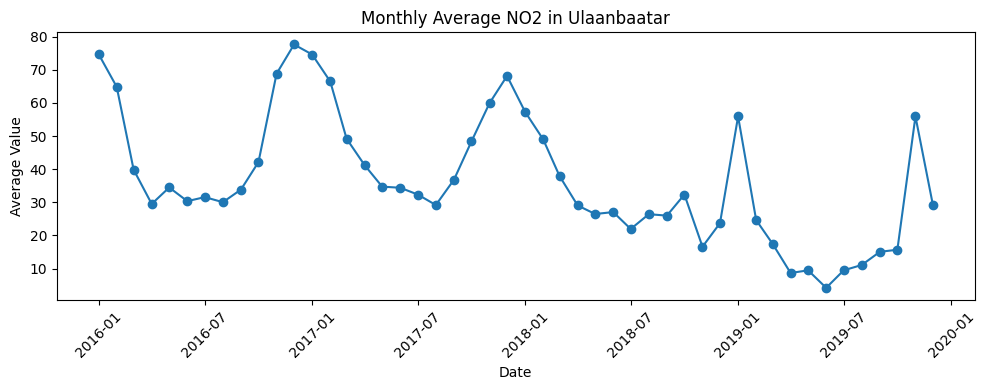

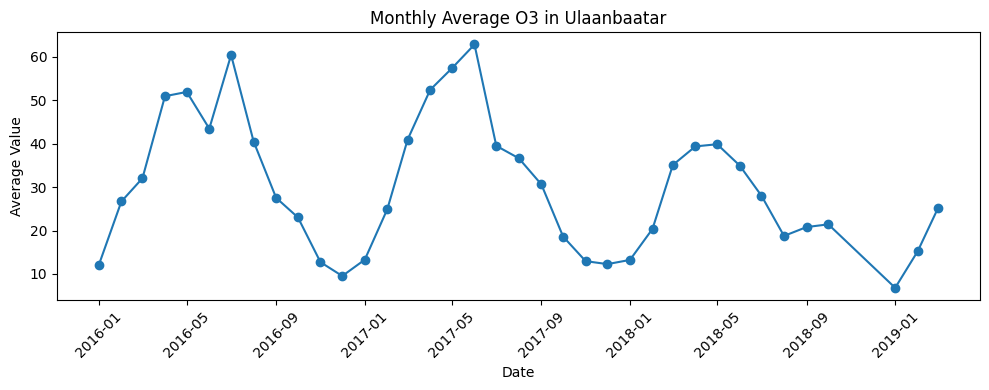

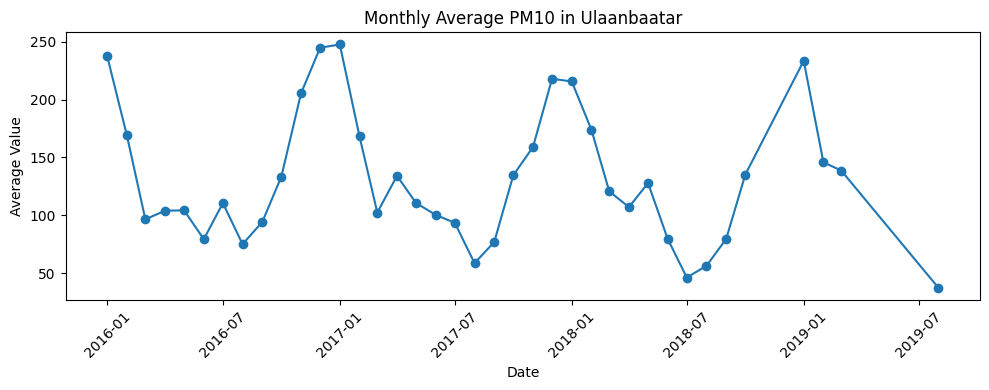

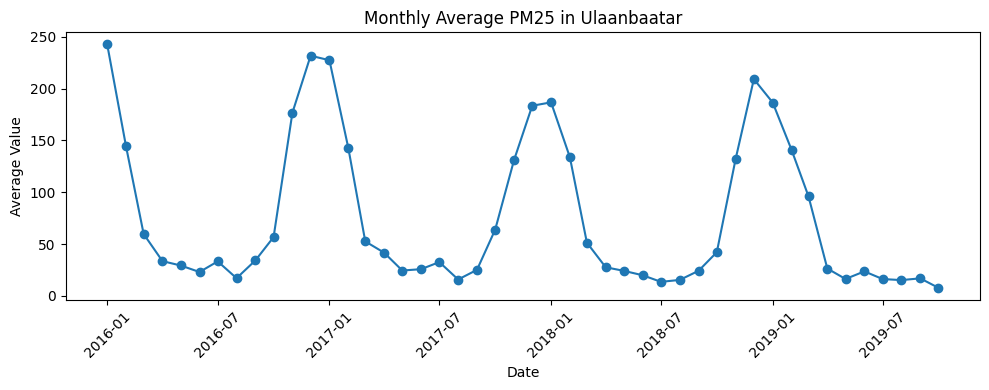

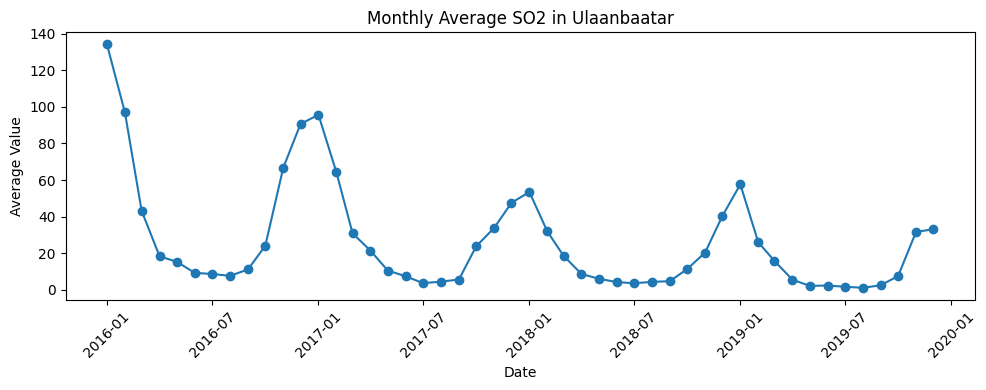

In [68]:
# Plot monthly trends for each pollutant across the full study period.

pollutants = sorted(air_monthly_city_df["parameter"].unique())

for pollutant in pollutants:
    subset = air_monthly_city_df[air_monthly_city_df["parameter"] == pollutant].sort_values("year_month")

    plt.figure(figsize=(10, 4))
    plt.plot(subset["year_month"], subset["avg_value"], marker="o")
    plt.title(f"Monthly Average {pollutant.upper()} in Ulaanbaatar")
    plt.xlabel("Date")
    plt.ylabel("Average Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"/content/project_website_figures/monthly_{pollutant}_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

## Compare annual average pollution levels across years

The monthly plots help show that several pollutants follow a repeated seasonal pattern, with clear winter spikes and lower values in warmer months. To make the year-to-year comparison more direct, I also calculate annual average levels for each pollutant.

In [10]:
# Calculate annual average pollutant levels.

annual_summary_df = (
    air_monthly_city_df
    .groupby(["year", "parameter"], as_index=False)["avg_value"]
    .mean()
)

display(annual_summary_df)

,year,parameter,avg_value
0,2016,co,1118.716411
1,2016,no2,46.475302
2,2016,o3,32.572592
3,2016,pm10,137.795230
4,2016,pm25,90.189554
5,2016,so2,43.802257
6,2017,co,1191.747582
7,2017,no2,47.938243
8,2017,o3,33.533042
9,2017,pm10,133.625427


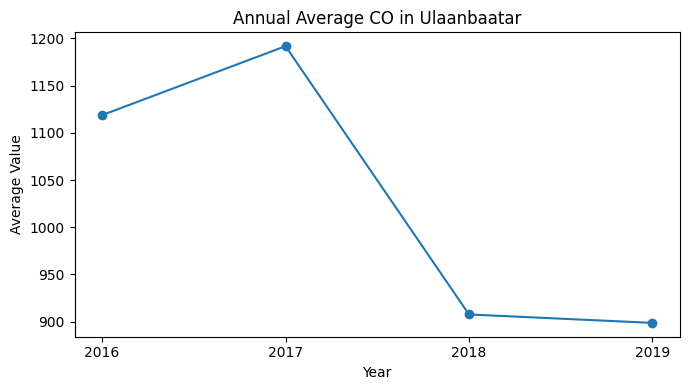

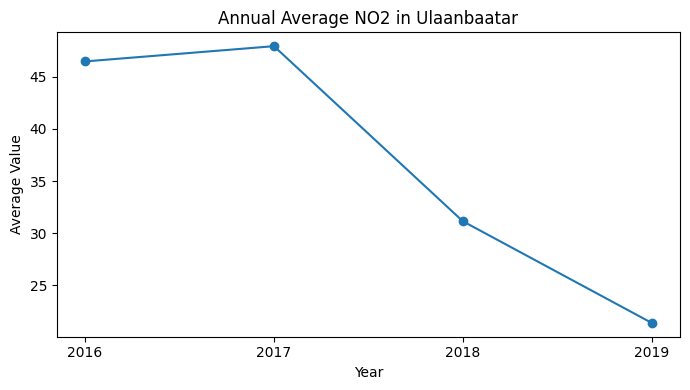

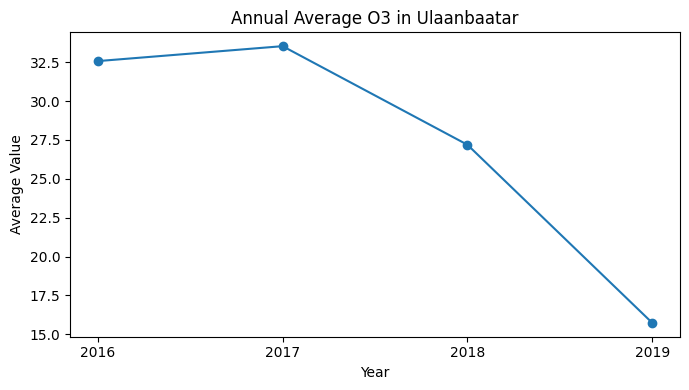

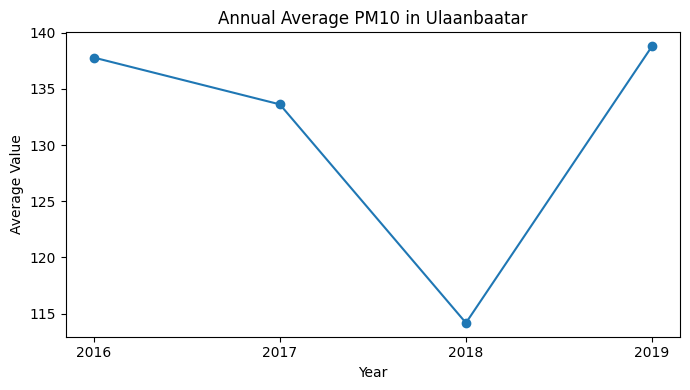

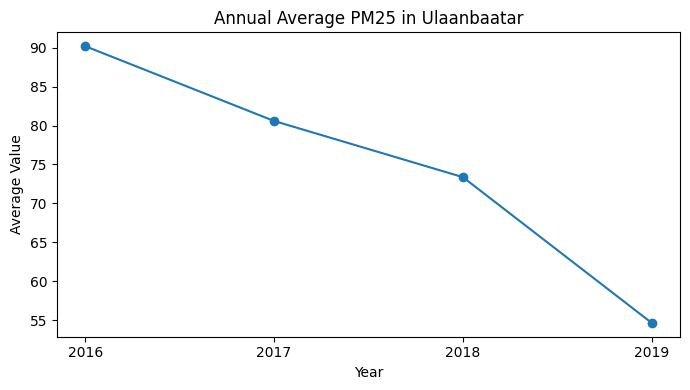

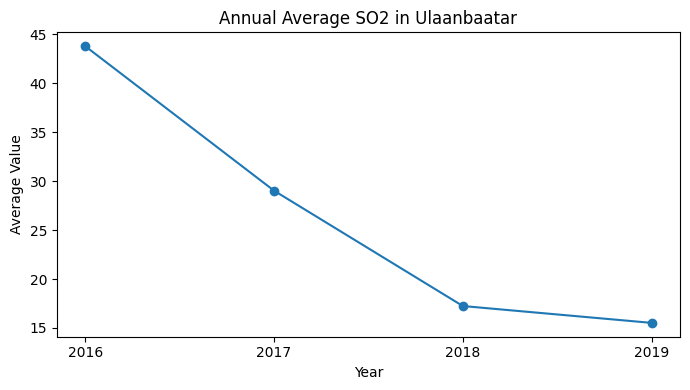

In [70]:
# Plot annual average pollutant levels by year.

pollutants = sorted(annual_summary_df["parameter"].unique())

for pollutant in pollutants:
    subset = annual_summary_df[annual_summary_df["parameter"] == pollutant].sort_values("year")

    plt.figure(figsize=(7, 4))
    plt.plot(subset["year"], subset["avg_value"], marker="o")
    plt.title(f"Annual Average {pollutant.upper()} in Ulaanbaatar")
    plt.xlabel("Year")
    plt.ylabel("Average Value")
    plt.xticks(subset["year"])
    plt.tight_layout()
    plt.savefig(f"/content/project_website_figures/annual_{pollutant}_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

## Compare how much pollutant levels changed from 2016 to 2019

The annual plots suggest that several pollutants decline over time, but the size of those changes is not the same for every pollutant. To make that comparison more direct, I calculate the absolute and percent change from 2016 to 2019 for each pollutant.

In [12]:
# Compare pollutant levels in 2016 and 2019 directly.

annual_change_df = annual_summary_df.pivot(
    index="parameter",
    columns="year",
    values="avg_value"
).reset_index()

annual_change_df["absolute_change_2016_to_2019"] = annual_change_df[2019] - annual_change_df[2016]
annual_change_df["percent_change_2016_to_2019"] = (
    (annual_change_df[2019] - annual_change_df[2016]) / annual_change_df[2016]
) * 100

annual_change_df = annual_change_df.sort_values("percent_change_2016_to_2019")

display(annual_change_df)

year,parameter,2016,2017,2018,2019,absolute_change_2016_to_2019,percent_change_2016_to_2019
5,so2,43.802257,29.032160,17.241049,15.519182,-28.283075,-64.569903
1,no2,46.475302,47.938243,31.141874,21.388945,-25.086358,-53.977825
2,o3,32.572592,33.533042,27.189528,15.730476,-16.842116,-51.706403
4,pm25,90.189554,80.584060,73.368016,54.650323,-35.539232,-39.405042
0,co,1118.716411,1191.747582,907.609143,898.683612,-220.032799,-19.668327
3,pm10,137.795230,133.625427,114.170243,138.807035,1.011806,0.734282


## Main takeaway from Question 1

The time analysis shows that air pollution in Ulaanbaatar has a very strong seasonal pattern. Winter levels are much higher than summer levels for most major pollutants, especially SO2, PM2.5, and CO. This suggests that pollution is not evenly distributed across the year and becomes much more severe during colder months.

At the same time, the yearly analysis shows that not all pollutants follow the same long-term pattern. Several pollutants, including PM2.5 and SO2, decline from 2016 to 2019, while PM10 does not follow the same steady drop and rises again in 2019. O3 also behaves differently from the other pollutants because it is higher in warmer seasons instead of winter.

Overall, this suggests that air pollution in Ulaanbaatar is shaped both by strong seasonal cycles and by pollutant-specific long-term trends.

# Which monitoring stations show the worst pollution levels, and do stations group into different pollution profiles?

After looking at time patterns across the city as a whole, I also want to understand how pollution differs across monitoring stations. This is important because city-wide averages can hide local variation. Some stations may consistently show much worse pollution than others, and different stations may also have different pollutant profiles.

In [13]:
# Inspect the station-level summary dataset before starting the station analysis.

print("Number of unique stations:", air_station_summary_df["station_name"].nunique())

print("\nPollutants in station summary dataset:")
print(sorted(air_station_summary_df["parameter"].unique()))

print("\nFirst 10 rows of station summary dataset:")
display(air_station_summary_df.head(10))

Number of unique stations: 20

Pollutants in station summary dataset:
['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']

First 10 rows of station summary dataset:


,location_id,station_name,parameter,avg_value,median_value,min_value,max_value,number_of_readings,first_date,last_date,avg_percent_coverage
0,19,MNB,o3,45.082246,40.60,3.000,248.0,690,2016-01-29,2018-10-18,87.769565
1,19,MNB,pm10,139.516356,117.00,7.830,728.0,999,2016-01-29,2019-03-13,85.314314
2,19,MNB,pm25,96.797518,55.10,5.330,713.0,999,2016-01-29,2019-03-13,85.314314
3,19,MNB,so2,67.516753,40.25,0.000,314.0,770,2016-01-29,2019-03-13,87.903896
4,23,Amgalan,co,1026.613219,631.00,127.000,7310.0,817,2016-01-29,2018-07-25,83.331701
5,23,Amgalan,no2,32.572324,27.70,1.110,90.8,981,2016-01-29,2019-03-13,84.891947
6,23,Amgalan,o3,50.844290,50.50,4.410,110.0,909,2016-01-29,2018-10-31,84.184818
7,23,Amgalan,pm10,123.609246,114.00,3.000,510.0,968,2016-02-02,2019-03-13,84.421488
8,23,Amgalan,pm25,61.971684,39.60,3.000,364.0,968,2016-02-02,2019-03-13,84.429752
9,23,Amgalan,so2,35.817617,16.50,0.333,326.0,951,2016-01-29,2019-03-13,85.310200


In [14]:
# Find the stations with the highest average PM2.5 levels.

pm25_station_df = (
    air_station_summary_df[air_station_summary_df["parameter"] == "pm25"]
    .sort_values("avg_value", ascending=False)
    .reset_index(drop=True)
)

display(pm25_station_df[["station_name", "avg_value", "median_value", "number_of_readings"]].head(10))

,station_name,avg_value,median_value,number_of_readings
0,Bayankhoshuu,131.058847,49.60,841
1,1-r khoroolol,115.550000,103.50,14
2,Tolgoit,102.274286,49.55,942
3,MNB,96.797518,55.10,999
4,Baruun 4 zam,69.144506,33.40,981
5,Ulaanbaatar,66.941378,27.05,898
6,Nisekh,63.368395,38.30,947
7,Amgalan,61.971684,39.60,968
8,US Diplomatic Post: Ulaanbaatar,55.769474,30.00,285
9,Bukhiin urguu,50.876360,28.95,1000


In [15]:
# Find the stations with the highest average PM10 levels.

pm10_station_df = (
    air_station_summary_df[air_station_summary_df["parameter"] == "pm10"]
    .sort_values("avg_value", ascending=False)
    .reset_index(drop=True)
)

display(pm10_station_df[["station_name", "avg_value", "median_value", "number_of_readings"]].head(10))

,station_name,avg_value,median_value,number_of_readings
0,Bayankhoshuu,221.473738,169.00,840
1,100 ail,168.743940,135.50,1000
2,1-r khoroolol,166.421429,159.00,14
3,Mongol gazar,157.631657,137.00,875
4,Tolgoit,154.925000,125.00,942
5,MNB,139.516356,117.00,999
6,Amgalan,123.609246,114.00,968
7,Baruun 4 zam,119.094980,95.35,988
8,Bukhiin urguu,113.151110,92.80,1000
9,Nisekh,112.103675,103.00,947


In [16]:
# Reshape the station summary data into a wide station-by-pollutant table.

station_profile_df = air_station_summary_df.pivot_table(
    index=["location_id", "station_name"],
    columns="parameter",
    values="avg_value"
).reset_index()

print("Shape of station-by-pollutant matrix:", station_profile_df.shape)
display(station_profile_df)

Shape of station-by-pollutant matrix: (20, 8)


parameter,location_id,station_name,co,no2,o3,pm10,pm25,so2
0,19,MNB,NaN,NaN,45.082246,139.516356,96.797518,67.516753
1,23,Amgalan,1026.613219,32.572324,50.844290,123.609246,61.971684,35.817617
2,30,100 ail,1237.588858,38.011717,26.235452,168.743940,NaN,29.044448
3,46,Bukhiin urguu,1012.119563,76.692230,15.775987,113.151110,50.876360,25.499662
4,48,Baruun 4 zam,1357.326535,94.647495,NaN,119.094980,69.144506,22.895384
5,59,Nisekh,638.556701,16.070032,28.761727,112.103675,63.368395,9.479002
6,90,Misheel expo,320.955962,22.972977,28.119003,80.878707,NaN,25.944199
7,694,Urgakh naran,477.636876,29.157150,4.637447,77.545690,NaN,22.794547
8,811,Tolgoit,1733.538195,31.799378,47.338715,154.925000,102.274286,42.252641
9,2275,Bayankhoshuu,NaN,NaN,NaN,221.473738,131.058847,35.107722


In [17]:
# Check for missing pollutant values after pivoting.

print("Missing values by column in station profile matrix:")
print(station_profile_df.isna().sum())

Missing values by column in station profile matrix:
parameter
location_id      0
station_name     0
co              10
no2              4
o3              12
pm10             7
pm25            10
so2              3
dtype: int64


## Handle missing pollutant values before clustering

The station-by-pollutant matrix is useful, but not every station has measurements for all six pollutants. For further analysis, I need a more complete matrix. So, Instead of forcing every station into the next step, I keep only the stations that have enough pollutant coverage to describe a meaningful pollution profile. Then I fill the remaining missing values with column averages so that the clustering can run on a complete matrix.

In [18]:
# Count how many pollutant values each station has.
pollutant_columns = ["co", "no2", "o3", "pm10", "pm25", "so2"]

station_profile_df["non_missing_pollutant_count"] = station_profile_df[pollutant_columns].notna().sum(axis=1)

display(
    station_profile_df[["station_name", "non_missing_pollutant_count"] + pollutant_columns]
    .sort_values("non_missing_pollutant_count", ascending=False)
)

parameter,station_name,non_missing_pollutant_count,co,no2,o3,pm10,pm25,so2
1,Amgalan,6,1026.613219,32.572324,50.844290,123.609246,61.971684,35.817617
3,Bukhiin urguu,6,1012.119563,76.692230,15.775987,113.151110,50.876360,25.499662
8,Tolgoit,6,1733.538195,31.799378,47.338715,154.925000,102.274286,42.252641
5,Nisekh,6,638.556701,16.070032,28.761727,112.103675,63.368395,9.479002
7,Urgakh naran,5,477.636876,29.157150,4.637447,77.545690,NaN,22.794547
2,100 ail,5,1237.588858,38.011717,26.235452,168.743940,NaN,29.044448
6,Misheel expo,5,320.955962,22.972977,28.119003,80.878707,NaN,25.944199
4,Baruun 4 zam,5,1357.326535,94.647495,NaN,119.094980,69.144506,22.895384
14,1-r khoroolol,5,24.178571,28.021429,NaN,166.421429,115.550000,31.050000
0,MNB,4,NaN,NaN,45.082246,139.516356,96.797518,67.516753


In [19]:
# Keep only stations with at least 4 of the 6 pollutants.

station_profile_filtered_df = station_profile_df[
    station_profile_df["non_missing_pollutant_count"] >= 4
].copy()

print("Number of stations kept for clustering:", len(station_profile_filtered_df))
display(station_profile_filtered_df[["station_name", "non_missing_pollutant_count"] + pollutant_columns])

Number of stations kept for clustering: 11


parameter,station_name,non_missing_pollutant_count,co,no2,o3,pm10,pm25,so2
0,MNB,4,NaN,NaN,45.082246,139.516356,96.797518,67.516753
1,Amgalan,6,1026.613219,32.572324,50.844290,123.609246,61.971684,35.817617
2,100 ail,5,1237.588858,38.011717,26.235452,168.743940,NaN,29.044448
3,Bukhiin urguu,6,1012.119563,76.692230,15.775987,113.151110,50.876360,25.499662
4,Baruun 4 zam,5,1357.326535,94.647495,NaN,119.094980,69.144506,22.895384
5,Nisekh,6,638.556701,16.070032,28.761727,112.103675,63.368395,9.479002
6,Misheel expo,5,320.955962,22.972977,28.119003,80.878707,NaN,25.944199
7,Urgakh naran,5,477.636876,29.157150,4.637447,77.545690,NaN,22.794547
8,Tolgoit,6,1733.538195,31.799378,47.338715,154.925000,102.274286,42.252641
11,Mongol gazar,4,876.427702,38.536017,NaN,157.631657,NaN,18.051188


In [21]:
# Fill remaining missing pollutant values with column means.

station_profile_clustering_df = station_profile_filtered_df.copy()

for col in pollutant_columns:
    station_profile_clustering_df[col] = station_profile_clustering_df[col].fillna(
        station_profile_clustering_df[col].mean()
    )


display(station_profile_clustering_df[["station_name"] + pollutant_columns])

parameter,station_name,co,no2,o3,pm10,pm25,so2
0,MNB,870.494218,40.848075,45.082246,139.516356,96.797518,67.516753
1,Amgalan,1026.613219,32.572324,50.844290,123.609246,61.971684,35.817617
2,100 ail,1237.588858,38.011717,26.235452,168.743940,79.997535,29.044448
3,Bukhiin urguu,1012.119563,76.692230,15.775987,113.151110,50.876360,25.499662
4,Baruun 4 zam,1357.326535,94.647495,30.849359,119.094980,69.144506,22.895384
5,Nisekh,638.556701,16.070032,28.761727,112.103675,63.368395,9.479002
6,Misheel expo,320.955962,22.972977,28.119003,80.878707,79.997535,25.944199
7,Urgakh naran,477.636876,29.157150,4.637447,77.545690,79.997535,22.794547
8,Tolgoit,1733.538195,31.799378,47.338715,154.925000,102.274286,42.252641
11,Mongol gazar,876.427702,38.536017,30.849359,157.631657,79.997535,18.051188


## Standardize the station pollutant profiles and apply clustering

Before clustering the stations, I need to standardize the pollutant columns. This is important because the pollutants are measured on very different scales, and I do not want one variable like CO to dominate the clustering just because it has larger numbers.

After standardizing the station profiles, I use k-means clustering to see whether the stations naturally group into different pollution patterns.

In [24]:
# Standardize the pollutant columns before clustering.

from sklearn.preprocessing import StandardScaler

pollutant_columns = ["co", "no2", "o3", "pm10", "pm25", "so2"]

scaler = StandardScaler()

station_scaled_array = scaler.fit_transform(
    station_profile_clustering_df[pollutant_columns]
)

station_scaled_df = pd.DataFrame(
    station_scaled_array,
    columns=pollutant_columns
)

station_scaled_df["station_name"] = station_profile_clustering_df["station_name"].values

display(station_scaled_df)

,co,no2,o3,pm10,pm25,so2,station_name
0,2.440279e-16,-3.155459e-16,1.106007e+00,0.361287,9.273975e-01,2.594346,MNB
1,3.351082e-01,-3.675189e-01,1.553762e+00,-0.160920,-9.950683e-01,0.400462,Amgalan
2,7.879656e-01,-1.259602e-01,-3.585366e-01,1.320784,-7.844717e-16,-0.068307,100 ail
3,3.039976e-01,1.591808e+00,-1.171319e+00,-0.504244,-1.607556e+00,-0.313640,Bukhiin urguu
4,1.044982e+00,2.389186e+00,-2.760736e-16,-0.309116,-5.991121e-01,-0.493881,Baruun 4 zam
5,-4.978520e-01,-1.100371e+00,-1.622253e-01,-0.538630,-9.179666e-01,-1.422424,Nisekh
6,-1.179579e+00,-7.938176e-01,-2.121700e-01,-1.563698,-7.844717e-16,-0.282874,Misheel expo
7,-8.432651e-01,-5.191838e-01,-2.036870e+00,-1.673116,-7.844717e-16,-0.500860,Urgakh naran
8,1.852517e+00,-4.018448e-01,1.281352e+00,0.867129,1.229728e+00,0.845827,Tolgoit
9,1.273618e-02,-1.026765e-01,-2.760736e-16,0.955985,-7.844717e-16,-0.829146,Mongol gazar


In [25]:
# Apply k-means clustering to the standardized station pollutant profiles.
# I am starting with 3 clusters

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

station_profile_clustering_df["cluster"] = kmeans.fit_predict(
    station_scaled_df[pollutant_columns]
)

display(
    station_profile_clustering_df[["station_name", "cluster"] + pollutant_columns]
    .sort_values(["cluster", "station_name"])
)

parameter,station_name,cluster,co,no2,o3,pm10,pm25,so2
14,1-r khoroolol,0,24.178571,28.021429,30.849359,166.421429,115.550000,31.050000
2,100 ail,0,1237.588858,38.011717,26.235452,168.743940,79.997535,29.044448
1,Amgalan,0,1026.613219,32.572324,50.844290,123.609246,61.971684,35.817617
0,MNB,0,870.494218,40.848075,45.082246,139.516356,96.797518,67.516753
11,Mongol gazar,0,876.427702,38.536017,30.849359,157.631657,79.997535,18.051188
8,Tolgoit,0,1733.538195,31.799378,47.338715,154.925000,102.274286,42.252641
6,Misheel expo,1,320.955962,22.972977,28.119003,80.878707,79.997535,25.944199
5,Nisekh,1,638.556701,16.070032,28.761727,112.103675,63.368395,9.479002
7,Urgakh naran,1,477.636876,29.157150,4.637447,77.545690,79.997535,22.794547
4,Baruun 4 zam,2,1357.326535,94.647495,30.849359,119.094980,69.144506,22.895384


In [26]:
# Calculate the average pollutant profile inside each cluster.

cluster_summary_df = (
    station_profile_clustering_df
    .groupby("cluster", as_index=False)[pollutant_columns]
    .mean()
)

display(cluster_summary_df)

parameter,cluster,co,no2,o3,pm10,pm25,so2
0,0,961.473461,34.964823,38.533237,151.807938,89.431426,37.288775
1,1,479.049846,22.733386,20.506059,90.176024,74.454489,19.405916
2,2,1184.723049,85.669862,23.312673,116.123045,60.010433,24.197523


## Compare the pollution profiles of the station clusters

The clustering results suggest that the stations do not all behave the same way. Instead, they seem to fall into a few broader pollution profiles. To make those differences easier to interpret, I compare the average pollutant levels in each cluster side by side.

In [28]:
# Make a cleaner version of the cluster summary table for plotting.

cluster_profile_df = cluster_summary_df.set_index("cluster")

display(cluster_profile_df)

parameter,co,no2,o3,pm10,pm25,so2
cluster,,,,,,
0,961.473461,34.964823,38.533237,151.807938,89.431426,37.288775
1,479.049846,22.733386,20.506059,90.176024,74.454489,19.405916
2,1184.723049,85.669862,23.312673,116.123045,60.010433,24.197523


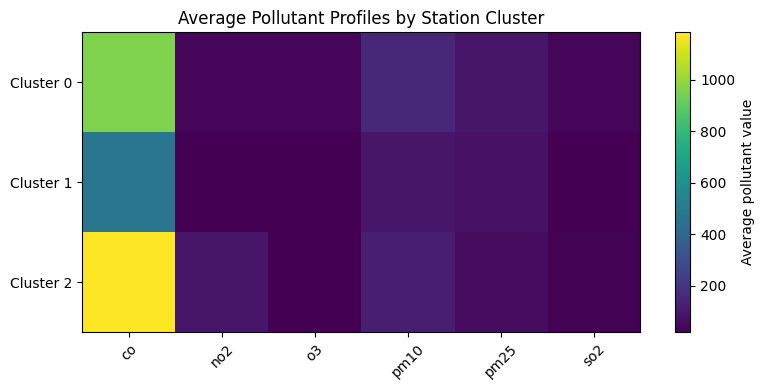

In [29]:
# Plot a heatmap of the cluster-average pollutant profiles.

plt.figure(figsize=(8, 4))
plt.imshow(cluster_profile_df, aspect="auto")
plt.colorbar(label="Average pollutant value")

plt.xticks(range(len(cluster_profile_df.columns)), cluster_profile_df.columns, rotation=45)
plt.yticks(range(len(cluster_profile_df.index)), [f"Cluster {c}" for c in cluster_profile_df.index])

plt.title("Average Pollutant Profiles by Station Cluster")
plt.tight_layout()
plt.show()

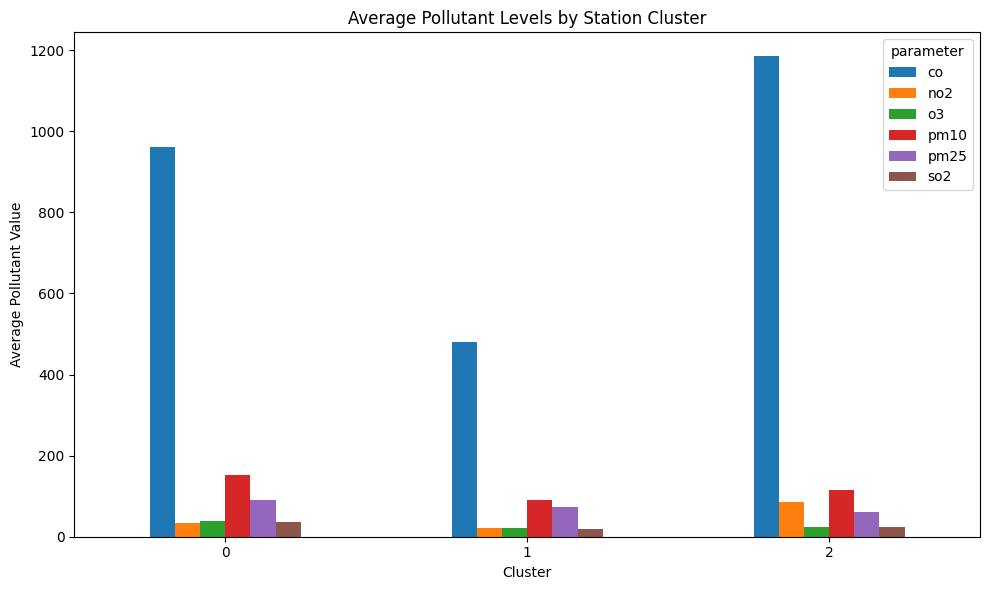

In [71]:
# Plot cluster-average pollutant levels with grouped bars.

cluster_plot_df = cluster_summary_df.set_index("cluster")

cluster_plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average Pollutant Levels by Station Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Pollutant Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/project_website_figures/station_cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpreting the station clusters

The clustering results suggest that the monitoring stations do not all behave the same way. Instead, they seem to fall into a few broader pollution profiles.

Cluster 0 appears to represent a broader high-pollution group. It includes stations such as MNB, 100 ail, Amgalan, Mongol gazar, and Tolgoit. These stations tend to have relatively high PM10, PM2.5, CO, and SO2 together, which suggests a more generally elevated pollution pattern.

Cluster 1 looks like a lower overall pollution group. It includes stations such as Nisekh, Misheel expo, and Urgakh naran. These stations have lower values across most pollutants, especially CO, NO2, PM10, and SO2.

Cluster 2 stands out as a more NO2-heavy or gas-heavy group. It includes stations such as Baruun 4 zam and Bukhiin urguu. Compared with the other clusters, this group has especially high NO2 while not being the most extreme for PM2.5.

Overall, the clustering suggests that different parts of the city share different multi-pollutant profiles rather than all following one single pollution pattern.

In [33]:
# Show the station names inside each cluster in a cleaner text form.
# This makes the clustering results easier to connect back to actual parts of the city.

cluster_station_lists = (
    station_profile_clustering_df.groupby("cluster")["station_name"]
    .apply(list)
    .reset_index()
)

display(cluster_station_lists)

,cluster,station_name
0,0,"[MNB, Amgalan, 100 ail, Tolgoit, Mongol gazar,..."
1,1,"[Nisekh, Misheel expo, Urgakh naran]"
2,2,"[Bukhiin urguu, Baruun 4 zam]"


## Map of monitoring stations by cluster

To make the station clustering easier to interpret, I also want to place the stations on a simple map using their approximate coordinates. This can help show whether parts of the city seem to share similar pollution profiles.

In [36]:
# Load the approximate station coordinates.

station_coords_df = pd.read_csv("/content/ub_station_coordinates.csv")

print("Shape of coordinate file:", station_coords_df.shape)
display(station_coords_df)

Shape of coordinate file: (11, 3)


,station_name,latitude,longitude
0,MNP,47.92972,106.888636
1,Amgalan,47.91350,106.998000
2,100 ail,47.93300,106.921400
3,Tolgoit,47.92230,106.794400
4,Mongol gazar,47.90510,106.841900
5,1-r khoroolol,47.91880,106.847800
6,Nisekh,47.86440,106.778300
7,Misheel expo,47.89400,106.882200
8,Urgakh naran,47.86650,107.118000
9,Bukhiin urguu,47.91760,106.937500


In [37]:
# Fix small station-name mismatches so the merge works better.

station_coords_df = station_coords_df.copy()
station_coords_df["station_name"] = station_coords_df["station_name"].replace({
    "MNP": "MNB"
})

display(station_coords_df)

,station_name,latitude,longitude
0,MNB,47.92972,106.888636
1,Amgalan,47.91350,106.998000
2,100 ail,47.93300,106.921400
3,Tolgoit,47.92230,106.794400
4,Mongol gazar,47.90510,106.841900
5,1-r khoroolol,47.91880,106.847800
6,Nisekh,47.86440,106.778300
7,Misheel expo,47.89400,106.882200
8,Urgakh naran,47.86650,107.118000
9,Bukhiin urguu,47.91760,106.937500


In [38]:
# Merge the station coordinates with the clustering results.
station_map_df = station_profile_clustering_df.merge(
    station_coords_df,
    on="station_name",
    how="inner"
)

print("Shape of mapped station dataset:", station_map_df.shape)
display(station_map_df[["station_name", "cluster", "latitude", "longitude", "pm25", "pm10"]])

Shape of mapped station dataset: (11, 12)


,station_name,cluster,latitude,longitude,pm25,pm10
0,MNB,0,47.92972,106.888636,96.797518,139.516356
1,Amgalan,0,47.91350,106.998000,61.971684,123.609246
2,100 ail,0,47.93300,106.921400,79.997535,168.743940
3,Bukhiin urguu,2,47.91760,106.937500,50.876360,113.151110
4,Baruun 4 zam,2,47.91550,106.894500,69.144506,119.094980
5,Nisekh,1,47.86440,106.778300,63.368395,112.103675
6,Misheel expo,1,47.89400,106.882200,79.997535,80.878707
7,Urgakh naran,1,47.86650,107.118000,79.997535,77.545690
8,Tolgoit,0,47.92230,106.794400,102.274286,154.925000
9,Mongol gazar,0,47.90510,106.841900,79.997535,157.631657


In [41]:
# Install the mapping libraries if they are not already available in Colab.

!pip install geopandas contextily --quiet

In [42]:
# Import the geospatial libraries for mapping.

import geopandas as gpd
import contextily as ctx

In [43]:
# Turn the station table into a GeoDataFrame using longitude and latitude.

station_map_gdf = gpd.GeoDataFrame(
    station_map_df.copy(),
    geometry=gpd.points_from_xy(station_map_df["longitude"], station_map_df["latitude"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator so it matches the basemap tiles.
station_map_gdf = station_map_gdf.to_crs(epsg=3857)

print("Shape of station map GeoDataFrame:", station_map_gdf.shape)
display(station_map_gdf[["station_name", "cluster", "pm25", "pm10", "geometry"]].head())

Shape of station map GeoDataFrame: (11, 13)


,station_name,cluster,pm25,pm10,geometry
0,MNB,0,96.797518,139.516356,POINT (11898788.531 6095170.701)
1,Amgalan,0,61.971684,123.609246,POINT (11910962.876 6092476.362)
2,100 ail,0,79.997535,168.743940,POINT (11902435.803 6095715.651)
3,Bukhiin urguu,2,50.876360,113.151110,POINT (11904228.047 6093157.342)
4,Baruun 4 zam,2,69.144506,119.094980,POINT (11899441.309 6092808.541)


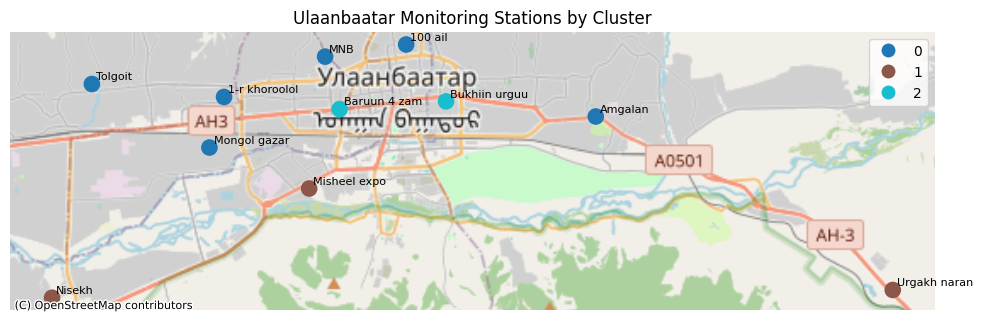

In [44]:
# Plot the station clusters on top of a real basemap.

fig, ax = plt.subplots(figsize=(10, 8))

station_map_gdf.plot(
    ax=ax,
    column="cluster",
    categorical=True,
    legend=True,
    markersize=120
)

# Add station labels
for _, row in station_map_gdf.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Ulaanbaatar Monitoring Stations by Cluster")
ax.set_axis_off()
plt.tight_layout()
plt.show()

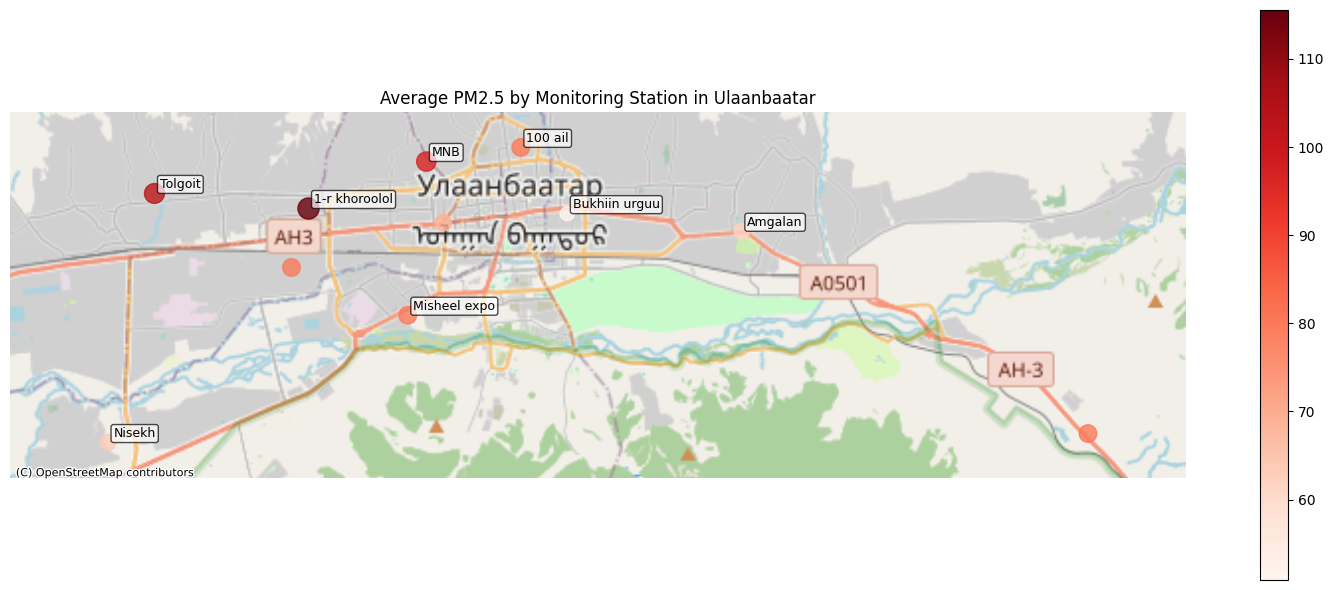

In [72]:
# Plot a cleaner PM2.5 station map on top of the basemap.

fig, ax = plt.subplots(figsize=(15, 6))

# Plot all stations
station_map_gdf.plot(
    ax=ax,
    column="pm25",
    cmap="Reds",
    legend=True,
    markersize=station_map_gdf["pm25"] * 2,
    alpha=0.8
)

# Label only the highest and lowest PM2.5 stations to reduce clutter
top_pm25_stations = station_map_gdf.nlargest(5, "pm25")
low_pm25_stations = station_map_gdf.nsmallest(3, "pm25")
label_df = pd.concat([top_pm25_stations, low_pm25_stations]).drop_duplicates(subset=["station_name"])

for _, row in label_df.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

# Add the basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Zoom in slightly around the station area
xmin, ymin, xmax, ymax = station_map_gdf.total_bounds
x_pad = (xmax - xmin) * 0.10
y_pad = (ymax - ymin) * 0.12

ax.set_xlim(xmin - x_pad, xmax + x_pad)
ax.set_ylim(ymin - y_pad, ymax + y_pad)

ax.set_title("Average PM2.5 by Monitoring Station in Ulaanbaatar")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("/content/project_website_figures/pm25_city_map.png", dpi=300, bbox_inches="tight")
plt.show()

### PM2.5 map interpretation

The map supports the earlier station-level results by showing that average PM2.5 is not evenly distributed across Ulaanbaatar. Some stations, such as Tolgoit and 1-r khoroolol, stand out with higher average PM2.5 levels, while others look noticeably lower. Even with approximate station coordinates, the map helps connect the pollution differences back to actual parts of the city.

# How are weather conditions associated with daily air pollution levels?

After looking at time trends and differences between station, I also wanted to understand whether daily weather conditions are associated with changes in air pollution. Since I already merged the city-level daily air data with daily weather data, I can now look at how variables like temperature, snowfall, precipitation, and wind speed relate to pollutant levels.

In [53]:
# Inspect the merged air and weather dataset before starting the weather analysis.

print("Shape of merged air + weather dataset:", air_weather_daily_df.shape)

print("\nPollutants in merged dataset:")
print(sorted(air_weather_daily_df["parameter"].unique()))

print("\nWeather columns available:")
weather_columns = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_mean",
    "precipitation_sum",
    "wind_speed_10m_mean",
    "snowfall_sum"
]
print(weather_columns)

print("\nFirst 5 rows:")
display(air_weather_daily_df.head())

Shape of merged air + weather dataset: (7146, 22)

Pollutants in merged dataset:
['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']

Weather columns available:
['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'snowfall_sum']

First 5 rows:


,date,year,month,season,parameter,avg_value,median_value,min_value,max_value,number_of_station_readings,...,temperature_2m_min,apparent_temperature_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,snowfall_sum,year_weather,month_weather,day,season_weather
0,2016-01-29,2016,1,Winter,co,1711.142857,1580.00,524.00,3880.0,7,...,-32.239502,-31.814425,-26.51867,0.0,8.496136,0.0,2016,1,29,Winter
1,2016-01-29,2016,1,Winter,no2,63.766667,67.55,35.00,83.9,6,...,-32.239502,-31.814425,-26.51867,0.0,8.496136,0.0,2016,1,29,Winter
2,2016-01-29,2016,1,Winter,o3,15.648571,15.60,1.44,28.2,7,...,-32.239502,-31.814425,-26.51867,0.0,8.496136,0.0,2016,1,29,Winter
3,2016-01-29,2016,1,Winter,pm10,177.662500,136.50,96.30,364.0,8,...,-32.239502,-31.814425,-26.51867,0.0,8.496136,0.0,2016,1,29,Winter
4,2016-01-29,2016,1,Winter,pm25,180.360000,135.00,88.80,298.0,5,...,-32.239502,-31.814425,-26.51867,0.0,8.496136,0.0,2016,1,29,Winter


## Compare pollutant levels with weather variables

To get a first sense of the relationships, I will start by calculating correlations between pollutant levels and the main weather variables. It shows whether some conditions, like colder temperatures or snowfall, tend to line up with higher pollution levels.

In [54]:
# Reshape the merged dataset into a wide daily table so each pollutant has its own column.

air_weather_wide_df = air_weather_daily_df.pivot_table(
    index="date",
    columns="parameter",
    values="avg_value"
).reset_index()

# Merge back one copy of the daily weather variables.
weather_daily_unique_df = (
    air_weather_daily_df[["date"] + weather_columns]
    .drop_duplicates()
    .copy()
)

air_weather_wide_df = air_weather_wide_df.merge(
    weather_daily_unique_df,
    on="date",
    how="left"
)

print("Shape of wide air + weather dataset:", air_weather_wide_df.shape)
display(air_weather_wide_df.head())

Shape of wide air + weather dataset: (1389, 14)


,date,co,no2,o3,pm10,pm25,so2,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,precipitation_sum,wind_speed_10m_mean,snowfall_sum
0,2016-01-29,1711.142857,63.766667,15.648571,177.662500,180.360000,105.728571,-26.518670,-18.989500,-32.239502,-31.814425,0.0,8.496136,0.0
1,2016-01-30,2801.571429,73.383333,9.886667,296.428571,272.500000,127.816667,-24.308252,-15.239500,-31.589500,-29.715456,0.0,9.551140,0.0
2,2016-01-31,2512.142857,86.983333,10.398571,245.375000,280.600000,168.042857,-19.814500,-11.689501,-25.039501,-25.316162,0.0,10.885971,0.0
3,2016-02-01,2954.142857,85.766667,14.908571,263.512500,276.200000,177.500000,-18.179087,-10.189501,-26.189500,-22.696518,0.0,4.454474,0.0
4,2016-02-02,2652.857143,92.150000,30.351429,226.111111,205.833333,156.700000,-18.947832,-11.739500,-23.189500,-23.720144,0.0,6.087335,0.0


In [55]:
# Calculate correlations between pollutant levels and weather variables.

pollutant_columns = ["co", "no2", "o3", "pm10", "pm25", "so2"]

correlation_df = air_weather_wide_df[pollutant_columns + weather_columns].corr()

pollutant_weather_corr_df = correlation_df.loc[pollutant_columns, weather_columns]

display(pollutant_weather_corr_df)

,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,precipitation_sum,wind_speed_10m_mean,snowfall_sum
co,-0.693191,-0.685650,-0.687607,-0.682512,-0.166697,-0.302954,-0.061597
no2,-0.552525,-0.535149,-0.566650,-0.543785,-0.174493,-0.285870,-0.039422
o3,0.590200,0.602318,0.559823,0.569550,0.071522,0.365754,0.036984
pm10,-0.589663,-0.570929,-0.604500,-0.588392,-0.276942,-0.320140,-0.127261
pm25,-0.769555,-0.762762,-0.765092,-0.755499,-0.194144,-0.357935,-0.072086
so2,-0.700160,-0.677519,-0.713125,-0.689174,-0.182670,-0.316792,-0.043430


## Interpret the weather correlations

The correlation table suggests that temperature is the strongest weather-related factor in this dataset. Most pollutants, especially PM2.5, SO2, and CO, are negatively correlated with temperature, which means pollution tends to be worse on colder days.

At the same time, O3 shows the opposite pattern and is positively correlated with temperature. Wind speed also shows moderate negative correlations with several pollutants, which suggests that windier days may help reduce pollution levels.

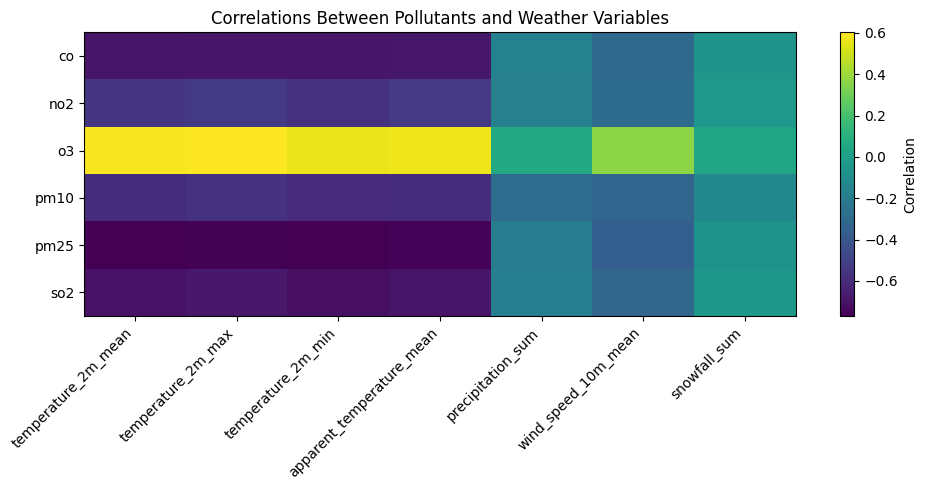

In [73]:
# Plot a heatmap of pollutant-weather correlations.

plt.figure(figsize=(10, 5))
plt.imshow(pollutant_weather_corr_df, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(weather_columns)), weather_columns, rotation=45, ha="right")
plt.yticks(range(len(pollutant_columns)), pollutant_columns)

plt.title("Correlations Between Pollutants and Weather Variables")
plt.tight_layout()
plt.savefig("/content/project_website_figures/weather_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
# Group days into temperature bins and compare average pollutant levels.

air_weather_wide_df["temperature_bin"] = pd.cut(
    air_weather_wide_df["temperature_2m_mean"],
    bins=[-40, -20, -10, 0, 10, 20, 30],
    labels=["Very cold", "Cold", "Cool", "Mild", "Warm", "Hot"]
)

temperature_bin_summary_df = (
    air_weather_wide_df.groupby("temperature_bin", observed=False)[pollutant_columns]
    .mean()
    .reset_index()
)

display(temperature_bin_summary_df)

,temperature_bin,co,no2,o3,pm10,pm25,so2
0,Very cold,2152.833410,53.223177,13.294492,223.882331,203.932515,60.545756
1,Cold,2144.584833,57.258616,16.569378,194.503106,169.643250,57.120746
2,Cool,870.427957,34.545742,28.896835,120.426699,71.695433,24.542911
3,Mild,679.120108,29.662182,35.925084,111.047433,34.548058,12.909627
4,Warm,425.536921,25.080939,38.357194,83.436696,20.627450,5.889727
5,Hot,510.196392,24.880178,50.165144,99.956097,24.604420,5.595906


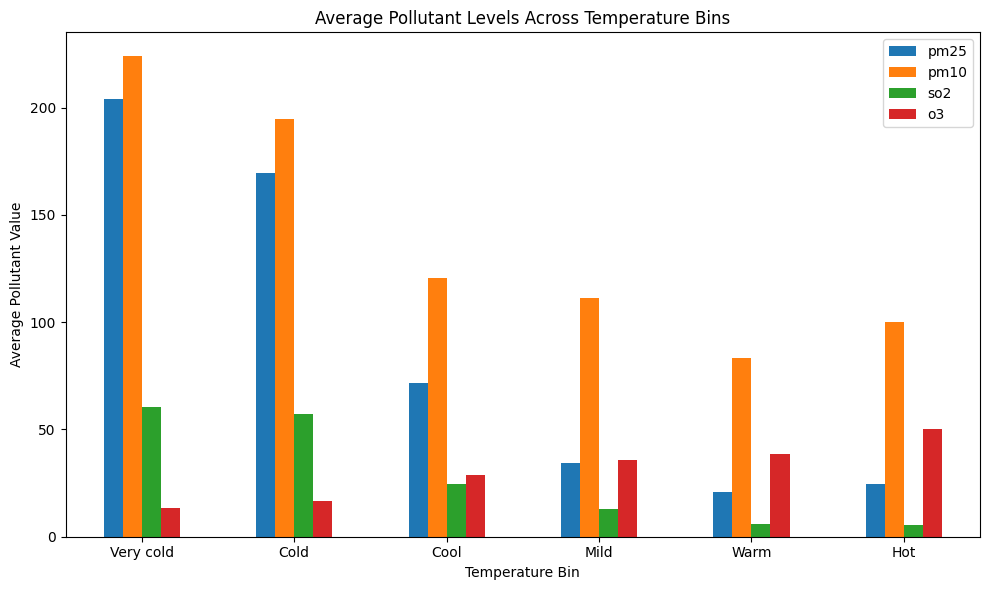

In [74]:
# Plot average pollutant levels across temperature bins.

focused_pollutants = ["pm25", "pm10", "so2", "o3"]

focused_temperature_plot_df = temperature_bin_summary_df.set_index("temperature_bin")[focused_pollutants]

focused_temperature_plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Average Pollutant Levels Across Temperature Bins")
plt.xlabel("Temperature Bin")
plt.ylabel("Average Pollutant Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/project_website_figures/temperature_bin_pollutants.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
# Build a regression dataset for PM2.5 using the wide daily air and weather data.

pm25_regression_df = air_weather_wide_df[
    ["pm25", "temperature_2m_mean", "wind_speed_10m_mean", "precipitation_sum", "snowfall_sum"]
].dropna().copy()

print("Shape of PM2.5 regression dataset:", pm25_regression_df.shape)
display(pm25_regression_df.head())

Shape of PM2.5 regression dataset: (1304, 5)


,pm25,temperature_2m_mean,wind_speed_10m_mean,precipitation_sum,snowfall_sum
0,180.360000,-26.518670,8.496136,0.0,0.0
1,272.500000,-24.308252,9.551140,0.0,0.0
2,280.600000,-19.814500,10.885971,0.0,0.0
3,276.200000,-18.179087,4.454474,0.0,0.0
4,205.833333,-18.947832,6.087335,0.0,0.0


In [62]:
# Fit a simple multiple linear regression model for PM2.5.

import statsmodels.api as sm

X = pm25_regression_df[["temperature_2m_mean", "wind_speed_10m_mean", "precipitation_sum", "snowfall_sum"]]
y = pm25_regression_df["pm25"]

X = sm.add_constant(X)

pm25_model = sm.OLS(y, X).fit()

print(pm25_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm25   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     564.5
Date:                Tue, 19 May 2026   Prob (F-statistic):          2.94e-282
Time:                        07:31:02   Log-Likelihood:                -6910.3
No. Observations:                1304   AIC:                         1.383e+04
Df Residuals:                    1299   BIC:                         1.386e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 123.0681    

## A simple regression model for PM2.5

To go beyond simple correlations, I also fit a multiple linear regression model using PM2.5 as the response variable and temperature, wind speed, precipitation, and snowfall as predictors.

The regression results support the earlier findings. Temperature remained the strongest variable in the model, with lower temperatures associated with higher PM2.5. Wind speed also showed a meaningful negative relationship with PM2.5, while precipitation did not appear to matter much in this model. Overall, the model explained a substantial share of the variation in daily PM2.5, which suggests that weather conditions are strongly associated with particulate pollution in Ulaanbaatar.

## Main takeaway from Question 3

The weather analysis suggests that temperature is the strongest weather-related factor in this dataset. Most pollutants, especially PM2.5, SO2, and CO, are much higher on colder days and much lower on warmer days. This pattern appears in the correlations, the temperature-bin comparisons, and the regression model.

The regression results also show that wind speed is associated with lower PM2.5 even after accounting for temperature and other weather variables. This suggests that both cold conditions and low wind are linked to worse particulate pollution. At the same time, O3 continues to behave differently from the other pollutants and tends to be higher on warmer days.

Overall, the weather results suggest that cold and stagnant conditions are strongly associated with worse air pollution in Ulaanbaatar.

## Limitations

This project has a few important limitations. First, not every monitoring station measured every pollutant, so some parts of the station analysis required filtering or imputation. Second, the map used approximate station coordinates rather than exact official station boundaries. Third, the weather analysis shows associations between variables, but it does not prove that weather directly causes changes in pollution. Even with these limits, the dataset was still strong enough to show clear patterns across time, stations, and weather conditions.

# Final Conclusion

In this project, I studied air pollution in Ulaanbaatar, Mongolia using daily air quality data and daily weather data from 2016 to 2019. Across the three main questions, the results showed that pollution in Ulaanbaatar is shaped by strong seasonal patterns, important station-level differences, and clear weather relationships.

First, the time analysis showed that most pollutants are much worse in winter than in summer. SO2 and PM2.5 had especially large winter-to-summer differences, while O3 showed the opposite pattern and was higher in warmer seasons. The yearly analysis also showed that not all pollutants changed in the same way over time. Several pollutants declined from 2016 to 2019, but PM10 did not follow the same steady improvement pattern.

Second, the station analysis showed that pollution is not evenly distributed across the city. Some monitoring stations had much higher PM2.5 and PM10 levels than others, and the clustering analysis suggested that stations can be grouped into broader pollution profiles. This means that different parts of Ulaanbaatar appear to experience different multi-pollutant conditions rather than one single citywide pattern.

Third, the weather analysis showed that temperature is strongly associated with pollution levels. Colder days were linked to much higher PM2.5, SO2, CO, and PM10, while O3 tended to be higher on warmer days. The regression model for PM2.5 also showed that temperature remained the strongest weather variable even after considering wind speed, precipitation, and snowfall together.


Overall, this project suggests that air pollution in Ulaanbaatar is driven by a combination of strong seasonality, local station differences, and weather conditions, especially temperature.

If I continued this project, and if I was able to find data for the possible variables that causes the air pollution, it would be great to see the correlation between different variables, rather than just temperature.

In [65]:
# Create a folder for the project website
import os

os.makedirs("/content/project_website_figures", exist_ok=True)